# 🔍 TRANSFORMER / BERT 실습

1. Self-Attention을 numpy로 직접 구현해보기
2. 실제 BERT 모델로 attention을 시각화하고 관찰하기

## 0. 환경 준비

In [1]:
!pip install -q transformers torch matplotlib seaborn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글이 깨지지 않도록 macOS 기본 한글 폰트를 설정합니다.
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='white', font='AppleGothic', rc={'axes.unicode_minus': False})


---
## Part 1. Self-Attention 직접 구현해보기

**핵심 수식**

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

우리는 "Cats are very independent animals" 라는 문장을 6개의 토큰으로 나눴다고 가정하고, 각 토큰을 8차원 벡터(임베딩)로 표현했다고 가정합니다.

아래 코드는 Self-Attention 계산 과정을 단계별로 구현한 풀이입니다.

In [3]:
tokens = ['Cats', 'are', 'very', 'independent', 'animals', '[EOS]']

seq_len = len(tokens)
d_model = 8   # 임베딩 차원
d_k = 8       # Q, K, V 차원 (간단히 동일하게 설정)

# 토큰 임베딩 (실제로는 학습되지만, 여기선 랜덤 벡터로 대체)
X = np.random.randn(seq_len, d_model)

# Q, K, V를 만들기 위한 가중치 행렬 (실제로는 학습되는 파라미터)
Wq = np.random.randn(d_model, d_k) * 0.1
Wk = np.random.randn(d_model, d_k) * 0.1
Wv = np.random.randn(d_model, d_k) * 0.1

print('X shape:', X.shape)


X shape: (6, 8)


In [4]:
# 1: X와 가중치 행렬을 곱해서 Q, K, V를 만듭니다.

Q = X @ Wq
K = X @ Wk
V = X @ Wv

print('Q shape:', Q.shape)


Q shape: (6, 8)


In [5]:
# 2: attention score를 계산합니다.
# scores = Q @ K.T / sqrt(d_k)

scores = Q @ K.T / np.sqrt(d_k)

print('scores shape:', scores.shape)


scores shape: (6, 6)


In [6]:
# 3: 각 행의 합이 1이 되도록 softmax를 적용해 attention weight를 만듭니다.

def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

attention_weights = softmax(scores, axis=-1)

# 4: attention weight와 V를 곱해 최종 output을 만듭니다.
output = attention_weights @ V

print('output shape:', output.shape)


output shape: (6, 8)


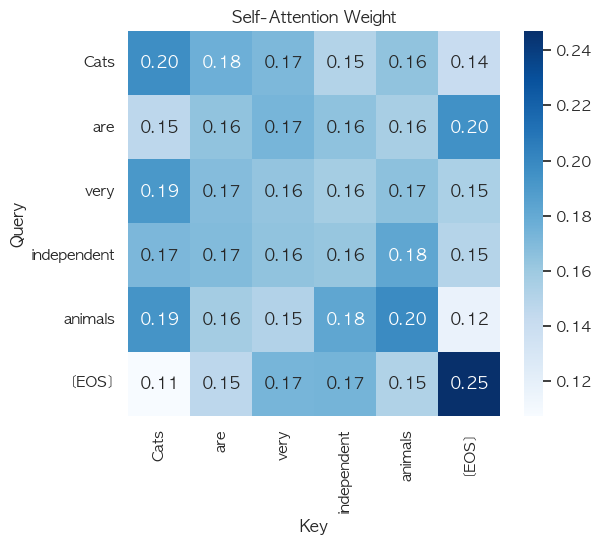

In [7]:
# 우리가 만든 attention weight를 시각화해봅시다
plt.figure(figsize=(6, 5))
sns.heatmap(attention_weights, xticklabels=tokens, yticklabels=tokens,
            annot=True, fmt='.2f', cmap='Blues')
plt.title('Self-Attention Weight')
plt.xlabel('Key')
plt.ylabel('Query')
plt.show()


### ✅ 정답

In [8]:
Q = X @ Wq
K = X @ Wk
V = X @ Wv

scores = Q @ K.T / np.sqrt(d_k)
attention_weights = softmax(scores)
output = attention_weights @ V

**생각해볼 질문**: 지금은 랜덤 가중치라 의미없는 패턴이 나옵니다. 실제 모델은 이 Wq, Wk, Wv를 학습을 통해 "의미있는" 값으로 채웁니다. Part 2에서 학습이 끝난 실제 모델은 어떤 패턴을 보이는지 확인해봅시다.

---
## Part 2. 실제 BERT 모델의 Attention 시각화

이번엔 실제로 학습된 다국어 BERT 모델(`bert-base-multilingual-cased`)을 불러와서, 한국어 문장을 넣고 attention이 어떻게 나오는지 확인해봅니다.

In [9]:
import torch
from transformers import AutoTokenizer, AutoModel

model_name = 'bert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p

In [10]:
# 문장을 바꿔가며 BERT attention을 관찰합니다.
sentence = '고양이는 매우 독립적인 동물이다'

inputs = tokenizer(sentence, return_tensors='pt')
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions  # (layer 개수) 튜플, 각 원소 shape: (batch, head, seq, seq)
tokens_bert = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

print('레이어 개수:', len(attentions))
print('헤드 개수:', attentions[0].shape[1])
print('토큰:', tokens_bert)


레이어 개수: 12
헤드 개수: 12
토큰: ['[CLS]', '고', '##양', '##이는', '매우', '독', '##립', '##적인', '동', '##물', '##이다', '[SEP]']


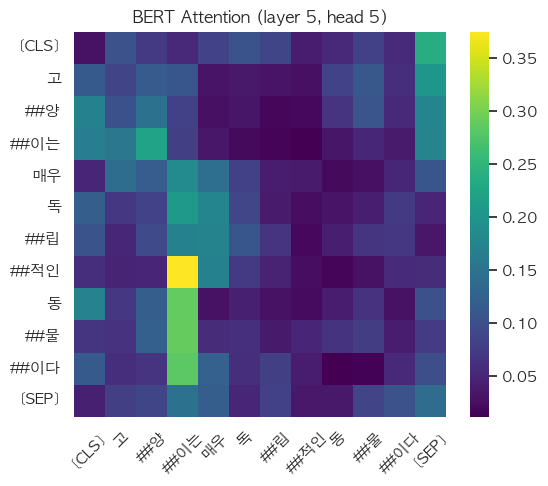

In [11]:
# 특정 레이어 / 특정 헤드의 attention을 시각화
layer = 5   # 0 ~ 11 사이 값으로 바꿔보세요
head = 5    # 0 ~ 11 사이 값으로 바꿔보세요

attn = attentions[layer][0, head].numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(attn, xticklabels=tokens_bert, yticklabels=tokens_bert, cmap='viridis')
plt.title(f'BERT Attention (layer {layer}, head {head})')
plt.xticks(rotation=45)
plt.show()


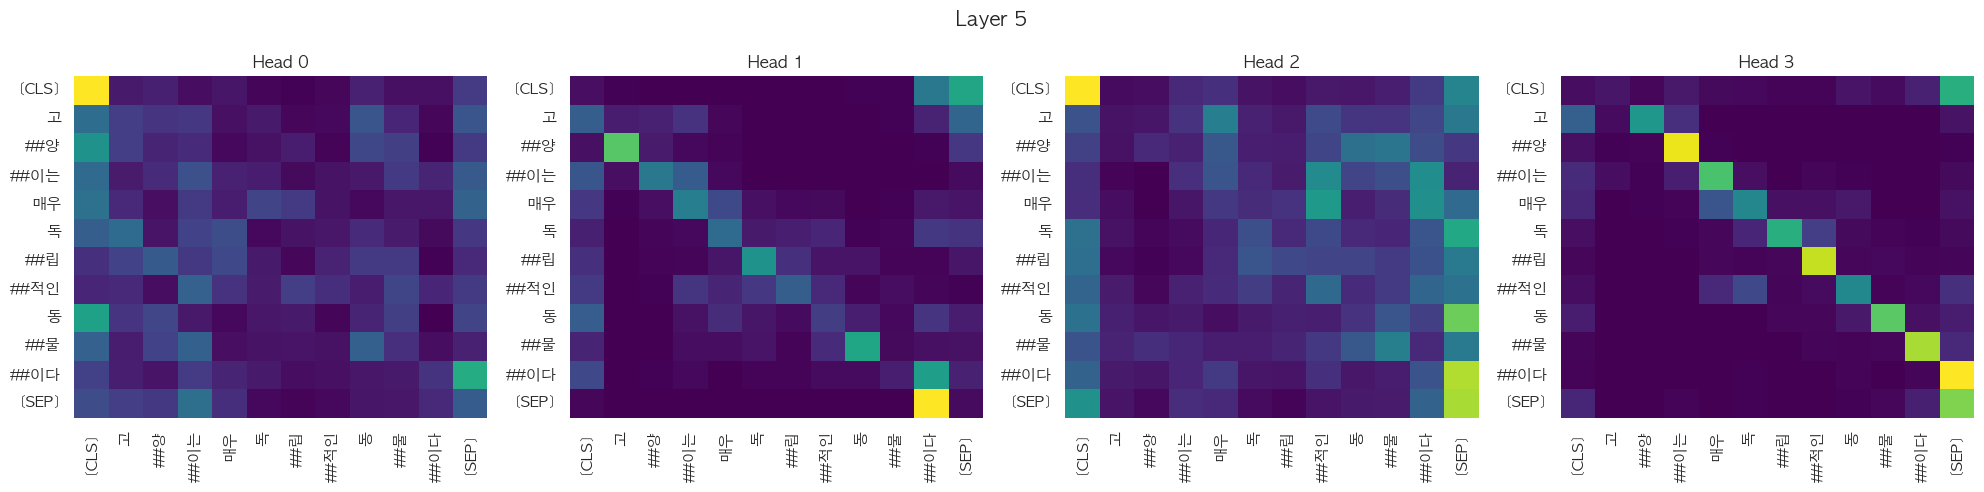

In [12]:
# 여러 헤드를 한번에 비교해보기 (같은 레이어, 여러 헤드)
layer = 5
num_heads_to_show = 4

fig, axes = plt.subplots(1, num_heads_to_show, figsize=(5 * num_heads_to_show, 5))
for h in range(num_heads_to_show):
    attn = attentions[layer][0, h].numpy()
    sns.heatmap(attn, xticklabels=tokens_bert, yticklabels=tokens_bert,
                cmap='viridis', ax=axes[h], cbar=False)
    axes[h].set_title(f'Head {h}')
    axes[h].tick_params(axis='x', rotation=90)
plt.suptitle(f'Layer {layer}')
plt.tight_layout()
plt.show()


### 🎯 실습 답안

1. `sentence`를 `고양이는 매우 독립적인 동물이다`로 바꾸어 실행했습니다. 한국어 문장을 사용하면 조사나 어미가 WordPiece 토큰으로 나뉘는 모습을 더 잘 관찰할 수 있습니다.
2. `layer`와 `head` 값을 바꿔 보면 head마다 attention 패턴이 다르게 나타납니다. 어떤 head는 대각선 방향이 강해서 각 토큰이 자기 자신을 많이 보고, 어떤 head는 `[CLS]`나 `[SEP]` 같은 특수 토큰에 attention이 몰립니다.
3. 관찰 결과 정리:
   - 특정 단어가 자기 자신에게 집중하는 head가 있습니다. heatmap에서 대각선 값이 진하게 나타나는 head가 여기에 해당합니다.
   - 한국어 문장에서는 조사/어미에 해당하는 subword 토큰이 앞의 명사나 주변 단어를 참고하는 패턴을 볼 수 있습니다. 예를 들어 `고양이는`이 여러 subword로 나뉘면 뒤쪽 조각이 앞쪽 조각이나 명사 부분을 보는 경우가 있습니다.
   - `[CLS]` 토큰에 attention이 몰리는 layer/head도 있습니다. 이는 `[CLS]`가 문장 전체 표현을 모으는 역할을 하기 때문에 자주 관찰되는 패턴입니다.


In [13]:
# 실습 답안을 확인하기 위한 보조 코드
# 자기 자신, [CLS], [SEP]에 attention이 강한 layer/head를 자동으로 찾아봅니다.

summary = []
for l, layer_attn in enumerate(attentions):
    # layer_attn shape: (batch, head, seq, seq)
    arr = layer_attn[0].detach().numpy()
    for h in range(arr.shape[0]):
        head_attn = arr[h]
        self_score = np.diag(head_attn).mean()
        cls_score = head_attn[:, 0].mean()
        sep_score = head_attn[:, -1].mean()
        summary.append((self_score, cls_score, sep_score, l, h))

best_self = max(summary, key=lambda x: x[0])
best_cls = max(summary, key=lambda x: x[1])
best_sep = max(summary, key=lambda x: x[2])

print(f'자기 자신 집중 head: layer {best_self[3]}, head {best_self[4]}, 평균 대각선 attention={best_self[0]:.3f}')
print(f'[CLS] 집중 head: layer {best_cls[3]}, head {best_cls[4]}, 평균 [CLS] attention={best_cls[1]:.3f}')
print(f'[SEP] 집중 head: layer {best_sep[3]}, head {best_sep[4]}, 평균 [SEP] attention={best_sep[2]:.3f}')


자기 자신 집중 head: layer 11, head 1, 평균 대각선 attention=0.828
[CLS] 집중 head: layer 2, head 10, 평균 [CLS] attention=0.905
[SEP] 집중 head: layer 0, head 0, 평균 [SEP] attention=0.355


---
## 정리

- Attention은 결국 "각 토큰이 문장 내 다른 토큰을 얼마나 참고할지"를 계산하는 것
- Q, K, V는 학습을 통해 의미있는 값을 갖게 되고, 그 결과로 head마다 서로 다른 문법적/의미적 패턴을 학습함
- 실제 Transformer는 이런 attention layer를 여러 개 쌓고, Feed-Forward, Residual/LayerNorm 등을 추가한 구조
- Transformer의 encoder 부분만 여러 층 쌓아서, 문장 전체를 양방향으로 보며 각 토큰의 의미를 학습하도록 만든 모델이 BERT